# NFL Quarterback Performance Analysis — corrected
## 1. Project Objective
Compare passing production, efficiency, observed time trends and contract associations. This is a descriptive portfolio analysis, not a causal model, scouting system or salary recommendation. “QB” is shorthand for participation-qualified passing players: the file has no position identifier.

The original 198-cell notebook and both XLSX inputs remain unchanged. See **AUDIT.md** for issue-level decisions and **cell-audit.csv** for every original cell (one-based numbering).

## 2. Data Sources
The supplied `Project 3 NFL Passing Statistics Analysis (Shachar Givon).xlsx`, sheet `NFL_Data`, supplies all observations. Its other sheets describe earlier enrichment, not additional records. The bilingual dictionary has 31 fields and predates contracts; `Season_Games` corresponds to `Games_In_Season`. Source attribution is inherited, not independent verification of every record.

Metric definitions: [Pro Football Reference glossary](https://www.pro-football-reference.com/about/glossary.htm) and [Pro Football Hall of Fame passer rating](https://www.profootballhof.com/news/nfl-s-passer-rating). No external player or contract observations are added.

In [1]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

filename = 'Project 3 NFL Passing Statistics Analysis (Shachar Givon).xlsx'
candidates = [Path.cwd(), Path.cwd() / 'python/nfl-quarterback-analysis']
DATA_DIR = next((p for p in candidates if (p / filename).exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Run from the repository root or this notebook directory.')
ASSETS = DATA_DIR / 'assets'
ASSETS.mkdir(exist_ok=True)
TABLES = DATA_DIR / 'tables'
TABLES.mkdir(exist_ok=True)
source_hashes = {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in DATA_DIR.glob('*.xlsx')}
workbook = pd.read_excel(DATA_DIR / filename, sheet_name=None)
raw = workbook['NFL_Data']
data = raw.copy(deep=True)
pd.set_option('display.max_columns', 15)
plt.rcParams.update({'figure.figsize': (10, 5.5), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
def save_chart(name):
    plt.tight_layout()
    plt.savefig(ASSETS / name, dpi=160, bbox_inches='tight')
    plt.show()
def show_table(frame, name):
    frame.to_csv(TABLES / (name + '.csv'), index=False)
    display(frame.round(3))
display(pd.DataFrame([{'sheet': k, 'rows': len(v), 'columns': len(v.columns)} for k,v in workbook.items()]))

sheet,rows,columns
NFL_Data,2246,36
Merge_Summary,17,2
Rookie_Scale_Summary,18,3
Year_Correction_Audit,108,14
Year_Correction_Summary,12,2
Identity_Correction_Audit,5,9
Final_Data_Quality_Check,8,2


## 3. Data Cleaning & Validation
Separate **data issues** (missing seasons, inconsistent metadata, ambiguous fields) from **analytical choices** (participation and longevity cutoffs). No rows are silently dropped or source cells repaired. Undefined rates remain missing. Source ratios are checked against counts before pooled metrics are calculated.

The dataset contains 2001–2023 observations **except 2007**. Never interpolate that season or call selected totals complete NFL totals. Multi-team codes `2TM`/`3TM` are player-season aggregates, retained for player analysis but excluded from team attribution. A player can appear in more games than one team's schedule after a trade; that flag alone is not an impossible value.

In [2]:
for column in ['Birthday', 'League_Entry_Date']:
    data[column] = pd.to_datetime(data[column], format='%d/%m/%Y', errors='coerce')
data['Years_in_League'] = data['Year'] - data['League_Entry_Date'].dt.year + 1
missing_seasons = sorted(set(range(int(data.Year.min()), int(data.Year.max()) + 1)) - set(data.Year))
validation = pd.DataFrame({'dtype': raw.dtypes.astype(str), 'missing': raw.isna().sum(),
                           'distinct': raw.nunique()}).rename_axis('field').reset_index()
show_table(validation, 'field_validation')
checks = {
    'duplicate full rows': raw.duplicated(),
    'duplicate player-season keys': raw.duplicated(['Player', 'Year'], keep=False),
    'games started exceeds games': data.GS > data.G,
    'games exceeds team schedule (review only)': data.G > data.Games_In_Season,
    'completions exceeds attempts': data.Cmp > data.Att,
    'TD exceeds completions': data.TD > data.Cmp,
    'interceptions exceeds attempts': data.Int > data.Att,
    'nonpositive attempts': data.Att <= 0,
    'negative count fields': data[['G','GS','Cmp','Att','TD','Int','Sk','Yds-s']].lt(0).any(axis=1),
    'fractional first-down count': data['1D'].mod(1).ne(0),
    'birth year vs age differs by more than one': (data.Year-data.Birthday.dt.year-data.Age).abs() > 1,
    'season precedes league entry': data.Years_in_League < 1,
    'unparseable date': data[['Birthday','League_Entry_Date']].isna().any(axis=1),
    'rating outside bounds': ~data.Rate.between(0, 158.334),
    'percentage outside 0-100': data[['Cmp%','TD%','Int%','Sk%']].lt(0).any(axis=1) | data[['Cmp%','TD%','Int%','Sk%']].gt(100).any(axis=1)
}
show_table(pd.DataFrame([{'check': k, 'flagged_rows': int(v.sum())} for k,v in checks.items()]), 'validation_checks')
flagged = pd.concat([raw.loc[v].assign(issue=k) for k,v in checks.items() if v.any()], ignore_index=True)
flagged.to_csv(TABLES / 'flagged_source_rows.csv', index=False)
assert not checks['duplicate player-season keys'].any(), 'Resolve keys before aggregation.'
assert not checks['negative count fields'].any()
print(f'{len(data):,} rows; {data.Player.nunique()} player names; {data.Year.nunique()} seasons; missing seasons: {missing_seasons}')

def rates(frame):
    out = frame.copy()
    att = out.Att.replace(0, np.nan)
    plays = (out.Att + out.Sk).replace(0, np.nan)
    out['Completion'] = 100 * out.Cmp / att
    out['ANYA'] = (out.Yds + 20*out.TD - 45*out.Int - out['Yds-s']) / plays
    out['NYA'] = (out.Yds - out['Yds-s']) / plays
    out['AYA'] = (out.Yds + 20*out.TD - 45*out.Int) / att
    a = (out.Cmp/att - .3)*5
    b = (out.Yds/att - 3)*.25
    c = out.TD/att*20
    d = 2.375 - out.Int/att*25
    out['Rating'] = (a.clip(0,2.375)+b.clip(0,2.375)+c.clip(0,2.375)+d.clip(0,2.375))*100/6
    out['TD_per_Game'] = out.TD / out.G.replace(0, np.nan)
    return out
data = rates(data)
ratio_checks = []
for source, derived, tolerance in [('Cmp%','Completion',.051),('ANY/A','ANYA',.0051),('NY/A','NYA',.0051),('Rate','Rating',.051)]:
    difference = (data[source]-data[derived]).abs()
    ratio_checks.append({'metric': source, 'outside_rounding_tolerance': int((difference>tolerance).sum()), 'maximum_difference': difference.max()})
show_table(pd.DataFrame(ratio_checks), 'ratio_checks')
show_table(data.groupby('Year').agg(rows=('Player','size'), players=('Player','nunique'), attempts=('Att','sum'), touchdowns=('TD','sum')).reset_index(), 'season_coverage')

field,dtype,missing,distinct
Player,str,0,715
Tm,str,0,37
Age,int64,0,25
Birthday,str,0,692
League_Entry_Date,str,0,39
G,int64,0,17
GS,int64,0,18
G%,float64,0,33
GS%,float64,0,33
Cmp,int64,0,406


check,flagged_rows
duplicate full rows,0
duplicate player-season keys,0
games started exceeds games,0
games exceeds team schedule (review only),1
completions exceeds attempts,0
TD exceeds completions,0
interceptions exceeds attempts,0
nonpositive attempts,0
negative count fields,0
fractional first-down count,1689


metric,outside_rounding_tolerance,maximum_difference
Cmp%,0,0.050
ANY/A,0,0.005
NY/A,0,0.005
Rate,0,0.050


Year,rows,players,attempts,touchdowns
2001,107,107,16181,635
2002,107,107,17292,694
2003,121,121,16493,654
2004,115,115,16354,732
2005,98,98,16464,644
2006,98,98,16389,648
2008,103,103,16526,646
2009,108,108,17033,710
2010,102,102,17269,751
2011,96,96,17410,745


2,246 rows; 715 player names; 22 seasons; missing seasons: [2007]


`1D` is excluded because fractional values contradict its count definition. Birthday inconsistencies are flagged, not guessed; age summaries use supplied `Age` and remain provisional. League-entry dates are not used for career eligibility. The old audit-sheet counts (2,350 rows) are historical, not current controls.

**Predeclared cohorts:** retain original `G > 5, Att > 10` for descriptive trends; `G > 5, Att > 30` and at least five observed qualifying seasons for career comparisons. These are sample-size choices, not position validation. Efficiency uses the same career cohort, avoiding the old exclusion of every player's first four league years. Show sensitivity to 3/5/7 qualifying seasons and 30/100/150 attempts. Age summaries retain `GS >= 5`. Contract relationships retain `G > 5, Att > 100`, then apply provenance/quality checks.

In [3]:
trend_rows = data.loc[(data.G > 5) & (data.Att > 10)].copy()
career_rows = data.loc[(data.G > 5) & (data.Att > 30)].copy()
age_rows = data.loc[data.GS >= 5].copy()
contract_candidates = data.loc[(data.G > 5) & (data.Att > 100)].copy()
show_table(pd.DataFrame([{'cohort': name, 'rows': len(f), 'players': f.Player.nunique()} for name,f in
 [('all',data),('trend: G>5, Att>10',trend_rows),('career input: G>5, Att>30',career_rows),('age: GS>=5',age_rows),('contract participation: G>5, Att>100',contract_candidates)]]), 'cohort_counts')
COUNT_COLUMNS = ['G','GS','Cmp','Att','Yds','TD','Int','Sk','Yds-s']
def aggregate(frame, by):
    grouped = frame.groupby(by, observed=True)
    totals = grouped[COUNT_COLUMNS].sum(min_count=1)
    totals['Seasons'] = grouped.Year.nunique()
    totals['Rows'] = grouped.size()
    totals['Players'] = grouped.Player.nunique()
    return rates(totals).reset_index()

cohort,rows,players
all,2246,715
"trend: G>5, Att>10",952,237
"career input: G>5, Att>30",927,234
age: GS>=5,1167,409
"contract participation: G>5, Att>100",878,221


## 4. Exploratory Data Analysis
Retain useful volume/efficiency correlations and team/age summaries. Correlations are descriptive Pearson coefficients with pairwise counts. Repeated players, playing-time selection and shared formula inputs prevent causal or independent-sample interpretations. Age bands weight player-seasons equally, rather than giving a rare age the same weight as a common age.

In [4]:
correlation_columns = ['G','Yds','TD','Rating','ANYA']
show_table(trend_rows[correlation_columns].corr().rename_axis('metric').reset_index(), 'volume_correlations')
team_counts = trend_rows.groupby(['Player','Tm']).Year.nunique().reset_index(name='qualifying_seasons')
long_tenure = team_counts.loc[team_counts.qualifying_seasons >= 5, ['Player','Tm']]
team_rows = trend_rows.merge(long_tenure, on=['Player','Tm'], how='inner', validate='many_to_one')
team_rows = team_rows.loc[~team_rows.Tm.isin(['2TM','3TM'])]
show_table(aggregate(team_rows, 'Tm').sort_values('Rating', ascending=False)[['Tm','Rows','Players','Rating','Completion','TD']], 'long_tenure_team_summary')
age_rows['Age_Band'] = pd.cut(age_rows.Age, [20,25,30,35,40,45], labels=['21–25','26–30','31–35','36–40','41–45'])
show_table(age_rows.groupby('Age_Band', observed=True).agg(rows=('Player','size'), players=('Player','nunique'), mean_rating=('Rating','mean'), mean_TD=('TD','mean'), mean_ANYA=('ANYA','mean')).reset_index(), 'age_summary')

metric,G,Yds,TD,Rating,ANYA
G,1.000,0.838,0.751,0.383,0.392
Yds,0.838,1.000,0.919,0.538,0.551
TD,0.751,0.919,1.000,0.643,0.630
Rating,0.383,0.538,0.643,1.000,0.948
ANYA,0.392,0.551,0.630,0.948,1.000


Tm,Rows,Players,Rating,Completion,TD
DAL,15,2,98.302,66.095,399
GNB,21,2,97.695,64.170,633
NOR,19,2,96.881,65.876,574
MIN,11,2,96.628,66.628,273
KAN,17,3,96.055,64.678,439
SDG,10,1,95.930,64.806,292
NWE,17,1,95.777,63.548,491
IND,15,2,94.492,64.183,454
PIT,16,1,93.170,64.448,386
SEA,19,2,92.603,62.757,438


Age_Band,rows,players,mean_rating,mean_TD,mean_ANYA
21–25,381,230,80.006,11.381,6.215
26–30,470,245,83.985,12.036,7.273
31–35,236,98,85.216,15.775,6.786
36–40,70,29,89.855,20.800,6.222
41–45,10,6,85.578,22.200,5.813


Team results describe only players with five qualifying seasons under the same source team code. They do not measure development ability; retaining successful players creates survivorship selection, and relocated franchises have separate codes. Age associations do not estimate within-player aging or an optimal age.

## 5. Career Performance Analysis
“Career” means available qualifying seasons in this workbook, not full NFL careers. Pool raw counts before deriving completion percentage, rating, NY/A and ANY/A. ANY/A divides by attempts **plus sacks**; TD/game uses games from exactly the same records as the TD numerator. An equal-season mean answers a different question and is retained as a comparison, not labeled pooled career efficiency. No rounding before ranking.

In [5]:
career_all = aggregate(career_rows, 'Player')
career = career_all.loc[career_all.Seasons >= 5].copy()
equal_season = career_rows.groupby('Player').agg(Mean_Season_Rating=('Rate','mean'), Mean_Season_ANYA=('ANY/A','mean')).reset_index()
career = career.merge(equal_season, on='Player', validate='one_to_one')
show_table(career.sort_values('Rating', ascending=False)[['Player','Seasons','Att','TD','TD_per_Game','Rating','Mean_Season_Rating','ANYA','Mean_Season_ANYA']], 'career_comparison')
assert career.Player.is_unique
assert np.isclose(career_all.TD.sum(), career_rows.TD.sum())

Player,Seasons,Att,TD,TD_per_Game,Rating,Mean_Season_Rating,ANYA,Mean_Season_ANYA
Aaron Rodgers,15,7601,474,2.126,103.806,103.827,7.387,7.388
Patrick Mahomes,6,3555,219,2.305,103.748,103.933,7.772,7.810
Deshaun Watson,6,2089,118,1.788,100.807,96.650,6.891,6.495
Russell Wilson,12,5665,334,1.777,100.004,100.175,6.799,6.815
Kirk Cousins,10,4974,262,1.845,99.365,99.060,6.972,7.003
Drew Brees,18,9872,542,2.007,99.292,99.161,7.160,7.133
Dak Prescott,7,3651,193,1.771,99.001,98.471,6.956,6.909
Peyton Manning,13,7186,423,2.094,98.934,98.092,7.359,7.299
Jimmy Garoppolo,7,1775,88,1.313,98.112,97.614,7.075,7.026
Lamar Jackson,6,2112,125,1.453,98.017,96.317,6.797,6.687


## 6. Passing Efficiency Analysis
Use pooled ANY/A as the primary efficiency comparison, accompanied by rating and completion percentage. Retire the old unnormalized Efficiency Score: rating's numerical scale overwhelms its nominal 20% weight, and its late-career-only cohort changes the research question. No new composite is chosen to favor a player.

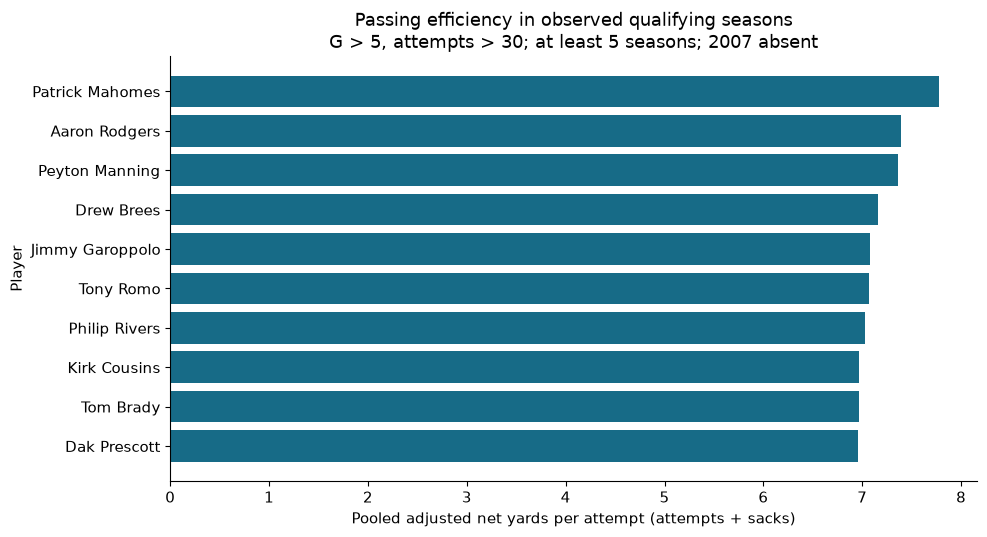

In [6]:
top_efficiency = career.nlargest(10, 'ANYA').sort_values('ANYA')
plt.figure()
plt.barh(top_efficiency.Player, top_efficiency.ANYA, color='#176b87')
plt.xlabel('Pooled adjusted net yards per attempt (attempts + sacks)')
plt.ylabel('Player')
plt.title('Passing efficiency in observed qualifying seasons\nG > 5, attempts > 30; at least 5 seasons; 2007 absent')
save_chart('efficiency-comparison.png')

## 7. Era / Time-Trend Analysis
Compute every era mask on the table being filtered. Display both original-style equal-season means and pooled rates. The first era includes only nine observed years. The last era spans three years. Schedule length, cohort composition and the missing year affect comparisons. These are descriptive changes, not evidence that an era caused improved ability. No significance tests were performed.

era,observed_seasons,rows,mean_annual_player_attempts,mean_annual_player_yards,mean_annual_total_TD,equal_year_mean_rating,pooled_rating,pooled_completion_pct,pooled_ANYA
2001–2010 (2007 absent),9,401,350.303,2426.654,638.111,79.424,82.347,60.235,5.592
2011–2020,10,411,406.833,2946.986,759.900,87.726,89.934,62.973,6.229
2021–2023,3,140,358.886,2545.248,725.667,87.367,90.751,64.785,6.042


era,metric,original_mask_mean,same_frame_mask_mean,original_years,correct_years
2001-2010,Att,377.169,350.303,"2001,2002,2003,2004,2005,2006,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023","2001,2002,2003,2004,2005,2006,2008,2009,2010"
2001-2010,Yds,2679.340,2426.654,"2001,2002,2003,2004,2005,2006,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023","2001,2002,2003,2004,2005,2006,2008,2009,2010"
2001-2010,TD,705.409,638.111,"2001,2002,2003,2004,2005,2006,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023","2001,2002,2003,2004,2005,2006,2008,2009,2010"
2001-2010,Int,423.091,465.000,"2001,2002,2003,2004,2005,2006,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023","2001,2002,2003,2004,2005,2006,2008,2009,2010"
2001-2010,Completion,61.245,59.216,"2001,2002,2003,2004,2005,2006,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023","2001,2002,2003,2004,2005,2006,2008,2009,2010"
2001-2010,Rating,84.281,79.426,"2001,2002,2003,2004,2005,2006,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023","2001,2002,2003,2004,2005,2006,2008,2009,2010"
2001-2010,ANYA,5.666,5.284,"2001,2002,2003,2004,2005,2006,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023","2001,2002,2003,2004,2005,2006,2008,2009,2010"
2011-2020,Att,395.768,406.832,"2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023","2011,2012,2013,2014,2015,2016,2017,2018,2019,2020"
2011-2020,Yds,2854.277,2946.985,"2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023","2011,2012,2013,2014,2015,2016,2017,2018,2019,2020"
2011-2020,TD,752.000,759.900,"2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023","2011,2012,2013,2014,2015,2016,2017,2018,2019,2020"


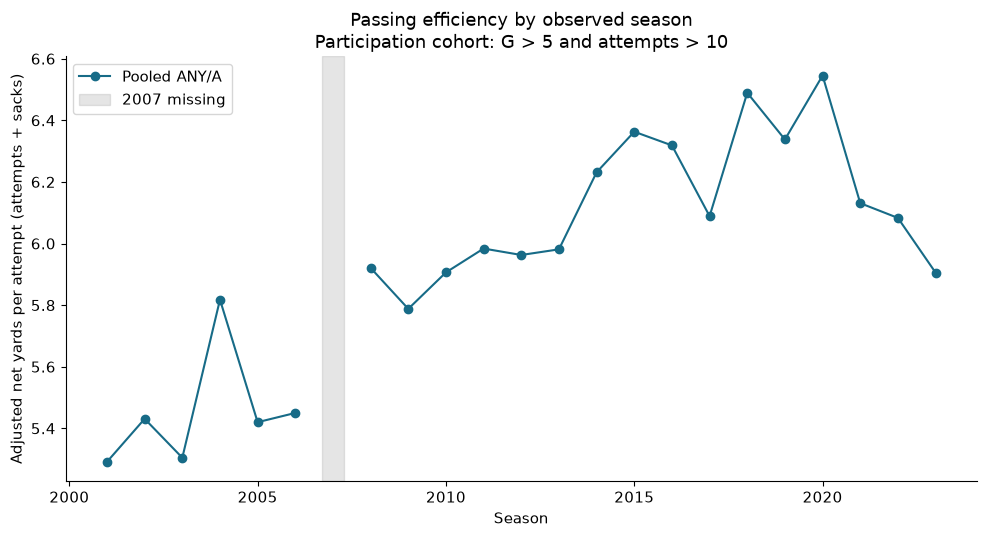

In [7]:
season = aggregate(trend_rows, 'Year')
season_means = trend_rows.groupby('Year').agg(Att=('Att','mean'),Yds=('Yds','mean'),TD=('TD','sum'),Int=('Int','sum'),Completion=('Cmp%','mean'),Rating=('Rate','mean'),ANYA=('ANY/A','mean')).reset_index()
era_records = []
for label, start, end in [('2001–2010 (2007 absent)',2001,2010),('2011–2020',2011,2020),('2021–2023',2021,2023)]:
    selected = trend_rows.loc[trend_rows.Year.between(start,end)]
    pooled = rates(selected[COUNT_COLUMNS].sum().to_frame().T).iloc[0]
    means = season_means.loc[season_means.Year.between(start,end)]
    era_records.append({'era':label,'observed_seasons':selected.Year.nunique(),'rows':len(selected),
        'mean_annual_player_attempts':means.Att.mean(), 'mean_annual_player_yards':means.Yds.mean(),
        'mean_annual_total_TD':means.TD.mean(), 'equal_year_mean_rating':means.Rating.mean(),
        'pooled_rating':pooled.Rating,'pooled_completion_pct':pooled.Completion,'pooled_ANYA':pooled.ANYA})
era = pd.DataFrame(era_records)
show_table(era, 'era_comparison')
mask_comparison=[]
legacy_season=season_means.round(2)
for start,end in [(2001,2010),(2011,2020)]:
    # Reproduce the original index-alignment error only for audit evidence.
    bad_mask=(legacy_season.Year>=start)&(raw.Year<=end)
    bad_rows=legacy_season.loc[bad_mask.reindex(legacy_season.index,fill_value=False)]
    good_rows=legacy_season.loc[legacy_season.Year.between(start,end)]
    for metric in ['Att','Yds','TD','Int','Completion','Rating','ANYA']:
        mask_comparison.append({'era':f'{start}-{end}','metric':metric,
            'original_mask_mean':bad_rows[metric].mean(),'same_frame_mask_mean':good_rows[metric].mean(),
            'original_years':','.join(bad_rows.Year.astype(str)),'correct_years':','.join(good_rows.Year.astype(str))})
show_table(pd.DataFrame(mask_comparison),'era-mask-before-after')
# Reindex explicitly so the missing 2007 observation breaks the line.
plot_season = season.set_index('Year').reindex(range(int(data.Year.min()),int(data.Year.max())+1))
plt.figure()
plt.plot(plot_season.index, plot_season.ANYA, marker='o', color='#176b87', label='Pooled ANY/A')
plt.axvspan(2006.7,2007.3,color='grey',alpha=.2,label='2007 missing')
plt.xlabel('Season'); plt.ylabel('Adjusted net yards per attempt (attempts + sacks)')
plt.title('Passing efficiency by observed season\nParticipation cohort: G > 5 and attempts > 10')
plt.legend(); save_chart('performance-trend.png')

## 8. QB Score Methodology
Retain the original **normalized** score as a transparent exploratory preference index, with corrected pooled inputs. The unnormalized predecessor is not a defensible weighted score because units determine influence.

|Metric|Weight|Direction|Normalization|
|---|---:|---|---|
|Pooled passer rating|25%|Higher|100 × value / cohort maximum|
|Pooled ANY/A|25%|Higher|Same|
|Pooled NY/A|15%|Higher|Same|
|Pooled completion %|15%|Higher|Same|
|Observed total TD|10%|Higher|Same|
|Observed TD/game|10%|Higher|Same|

Weights sum to one but are subjective. Rating already includes completions, yards, TD and interceptions; ANY/A overlaps with rating and NY/A; TD appears in multiple terms. Normalization does **not** remove this conceptual double counting or equalize variances. Total TD intentionally retains longevity influence. Five qualifying seasons excludes short careers and new entrants; incomplete career windows remain. Max scaling depends on the cohort, can be negative for negative metrics, and is not a percentile or validated 0–100 ability scale. All eligible values here are positive. This index is usable for descriptive comparison, not an objective “greatest QB” conclusion.

Keep weights fixed; inspect metric correlations, leave-one-component-out ranks and eligibility sensitivity. These are diagnostics, not a search for preferred rankings.

Player,Seasons,Rating,ANYA,NYA,Completion,TD,TD_per_Game,QB_Score
Aaron Rodgers,15,103.806,7.387,6.796,65.334,474,2.126,94.227
Drew Brees,18,99.292,7.160,7.090,67.737,542,2.007,94.163
Patrick Mahomes,6,103.748,7.772,7.343,66.498,219,2.305,93.347
Peyton Manning,13,98.934,7.359,7.304,66.435,423,2.094,93.256
Tom Brady,20,96.190,6.972,6.739,64.121,599,1.890,91.735
Philip Rivers,14,96.068,7.025,7.112,65.188,399,1.781,89.065
Kirk Cousins,10,99.365,6.972,6.832,67.370,262,1.845,87.589
Russell Wilson,12,100.004,6.799,6.490,64.748,334,1.777,86.814
Tony Romo,8,97.611,7.068,7.062,65.257,206,1.823,86.448
Dak Prescott,7,99.001,6.956,6.773,66.941,193,1.771,85.760


metric,Rating,ANYA,NYA,Completion,TD,TD_per_Game
Rating,1.000,0.949,0.827,0.874,0.575,0.760
ANYA,0.949,1.000,0.937,0.757,0.634,0.815
NYA,0.827,0.937,1.000,0.697,0.592,0.784
Completion,0.874,0.757,0.697,1.000,0.423,0.570
TD,0.575,0.634,0.592,0.423,1.000,0.749
TD_per_Game,0.760,0.815,0.784,0.570,0.749,1.000


Player,QB_Score_pooled,QB_Score_original
Aaron Rodgers,94.227,94.145
Drew Brees,94.163,93.798
Patrick Mahomes,93.347,93.390
Peyton Manning,93.256,92.596
Tom Brady,91.735,91.633
Philip Rivers,89.065,89.125
Kirk Cousins,87.589,87.577
Russell Wilson,86.814,86.769
Tony Romo,86.448,86.521
Dak Prescott,85.760,85.261


attempts_strictly_above,minimum_seasons,eligible_players,score_leader,ANYA_leader
30,3,120,Aaron Rodgers,Patrick Mahomes
30,5,75,Aaron Rodgers,Patrick Mahomes
30,7,39,Aaron Rodgers,Aaron Rodgers
100,3,115,Aaron Rodgers,Patrick Mahomes
100,5,74,Aaron Rodgers,Patrick Mahomes
100,7,34,Aaron Rodgers,Aaron Rodgers
150,3,107,Aaron Rodgers,Patrick Mahomes
150,5,70,Aaron Rodgers,Patrick Mahomes
150,7,34,Aaron Rodgers,Aaron Rodgers


Player,full_rank,without_Rating,without_ANYA,without_NYA,without_Completion,without_TD,without_TD_per_Game
Aaron Rodgers,1.0,3.0,2.0,1.0,1.0,2.0,2.0
Drew Brees,2.0,1.0,1.0,2.0,2.0,4.0,1.0
Patrick Mahomes,3.0,5.0,5.0,3.0,3.0,1.0,5.0
Peyton Manning,4.0,2.0,3.0,4.0,4.0,3.0,3.0
Tom Brady,5.0,4.0,4.0,5.0,5.0,11.0,4.0
Philip Rivers,6.0,6.0,6.0,6.0,6.0,9.0,6.0
Kirk Cousins,7.0,7.0,7.0,7.0,7.0,5.0,7.0
Russell Wilson,8.0,10.0,8.0,8.0,8.0,12.0,8.0
Tony Romo,9.0,9.0,11.0,9.0,9.0,6.0,9.0
Dak Prescott,10.0,12.0,12.0,10.0,11.0,8.0,12.0


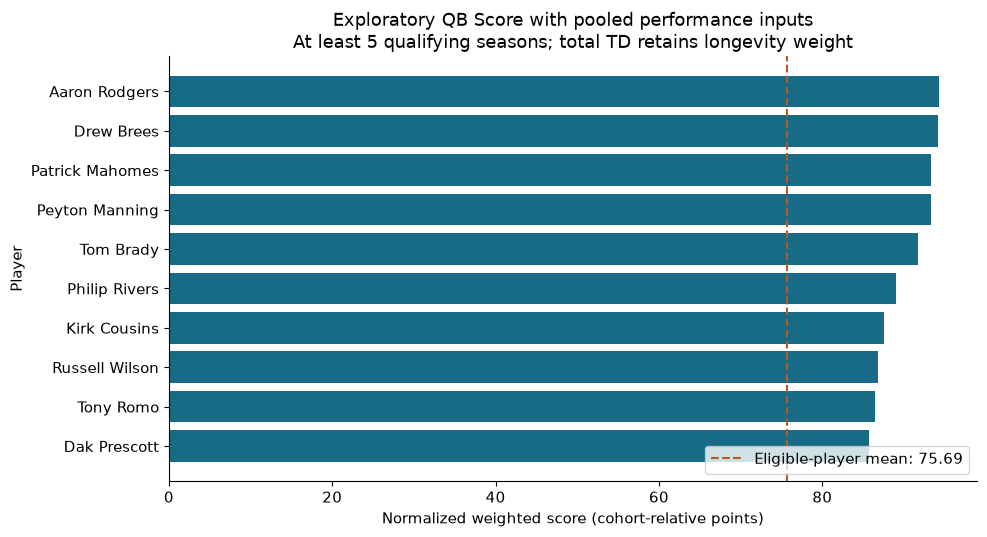

In [8]:
WEIGHTS = pd.Series({'Rating':.25,'ANYA':.25,'NYA':.15,'Completion':.15,'TD':.10,'TD_per_Game':.10})
def score(frame):
    frame = frame.copy()
    maxima = frame[WEIGHTS.index].max()
    assert maxima.gt(0).all() and np.isclose(WEIGHTS.sum(),1)
    frame['QB_Score'] = frame[WEIGHTS.index].div(maxima).mul(WEIGHTS).sum(axis=1)*100
    return frame
career = score(career)
show_table(career.sort_values('QB_Score',ascending=False)[['Player','Seasons',*WEIGHTS.index,'QB_Score']], 'qb_score')
show_table(career[list(WEIGHTS.index)].corr().rename_axis('metric').reset_index(), 'score_metric_correlations')
legacy = career_rows.groupby('Player').agg(Seasons=('Year','nunique'),Rating=('Rate','mean'),ANYA=('ANY/A','mean'),NYA=('NY/A','mean'),Completion=('Cmp%','mean'),TD=('TD','sum'),G=('G','sum')).reset_index()
legacy['TD_per_Game'] = (legacy.TD/legacy.G).round(2)
legacy = score(legacy.loc[legacy.Seasons>=5])
comparison = career[['Player','QB_Score']].merge(legacy[['Player','QB_Score']],on='Player',suffixes=('_pooled','_original'),validate='one_to_one')
show_table(comparison.sort_values('QB_Score_pooled',ascending=False), 'score_before_after')
sensitivity=[]
for min_attempts in [30,100,150]:
    rows=data.loc[(data.G>5)&(data.Att>min_attempts)]
    grouped=aggregate(rows,'Player')
    for min_seasons in [3,5,7]:
        eligible=score(grouped.loc[grouped.Seasons>=min_seasons])
        sensitivity.append({'attempts_strictly_above':min_attempts,'minimum_seasons':min_seasons,'eligible_players':len(eligible),'score_leader':eligible.loc[eligible.QB_Score.idxmax(),'Player'],'ANYA_leader':eligible.loc[eligible.ANYA.idxmax(),'Player']})
show_table(pd.DataFrame(sensitivity),'eligibility_sensitivity')
normalized=career[WEIGHTS.index]/career[WEIGHTS.index].max()*100
rank_sensitivity=career[['Player']].copy()
rank_sensitivity['full_rank']=career.QB_Score.rank(ascending=False,method='min')
for omitted in WEIGHTS.index:
    weights=WEIGHTS.drop(omitted); weights=weights/weights.sum()
    rank_sensitivity['without_'+omitted]=(normalized[weights.index]*weights).sum(axis=1).rank(ascending=False,method='min')
show_table(rank_sensitivity.sort_values('full_rank'), 'component_sensitivity')
top_score=career.nlargest(10,'QB_Score').sort_values('QB_Score')
plt.figure(); plt.barh(top_score.Player,top_score.QB_Score,color='#176b87')
plt.axvline(career.QB_Score.mean(),linestyle='--',color='#b35b24',label=f'Eligible-player mean: {career.QB_Score.mean():.2f}')
plt.xlabel('Normalized weighted score (cohort-relative points)'); plt.ylabel('Player')
plt.title('Exploratory QB Score with pooled performance inputs\nAt least 5 qualifying seasons; total TD retains longevity weight')
plt.legend(loc='lower right');save_chart('qb-score-comparison.png')

## 9. Contract Analysis
Classify provenance before filtering: **source-labeled historical**, **2026 rookie-scale estimate**, **missing**, or **other/unverified**. Historical attribution is not independent verification. Missing values remain missing; no medians are imputed. APY is average contract value per year, not realized pay, cap charge, guaranteed money or ROI.

Check signing year ≤ season < signing year + length, positive fields and APY ≈ value/length. A mismatch is a review flag: contract definitions may differ, so do not overwrite APY. Use a conservative reconciled subset for the main relationship and report sensitivity retaining flagged historical rows. Matching active intervals is only an annual approximation: signing day, extensions, releases and effective dates are unavailable.

Plot one player-season per point for performance relationships, and deduplicate contract tuples for signing-year comparisons. Same-year contracts may reflect information from that season, so this is contemporaneous association, not forecasting. No train/test or causal claims are made; in-sample fitted residuals are labeled as such.

Contract_Status,rows,players
2026 estimate,222,140
missing,942,448
source-labeled historical,1082,204


Year,Contract_Status,rows
2001,2026 estimate,14
2001,missing,77
2001,source-labeled historical,16
2002,2026 estimate,15
2002,missing,75
2002,source-labeled historical,17
2003,2026 estimate,22
2003,missing,81
2003,source-labeled historical,18
2004,2026 estimate,17


Player,Year,Contract_Status,Contract_Value,Contract_APY,Contract_Year_Signed,Contract_Length,APY_Reconciles
Drew Brees,2006,source-labeled historical,60000000.0,10000000.0,2006.0,5.0,False
Vince Young,2006,source-labeled historical,48040020.0,8006670.0,2006.0,4.0,False
Jason Campbell,2006,source-labeled historical,7500000.0,7500000.0,2005.0,5.0,False
Drew Brees,2008,source-labeled historical,60000000.0,10000000.0,2006.0,5.0,False
Jason Campbell,2008,source-labeled historical,7500000.0,7500000.0,2005.0,5.0,False
Kyle Orton,2008,source-labeled historical,3000000.0,3000000.0,2008.0,2.0,False
Vince Young,2008,source-labeled historical,48040020.0,8006670.0,2006.0,4.0,False
Drew Brees,2009,source-labeled historical,60000000.0,10000000.0,2006.0,5.0,False
Kyle Orton,2009,source-labeled historical,3000000.0,3000000.0,2008.0,2.0,False
Jason Campbell,2009,source-labeled historical,7500000.0,7500000.0,2005.0,5.0,False


sample,rows,players,pearson_APY_ANYA
historical before APY reconciliation,653,142,0.266
reconciled historical main,627,139,0.272


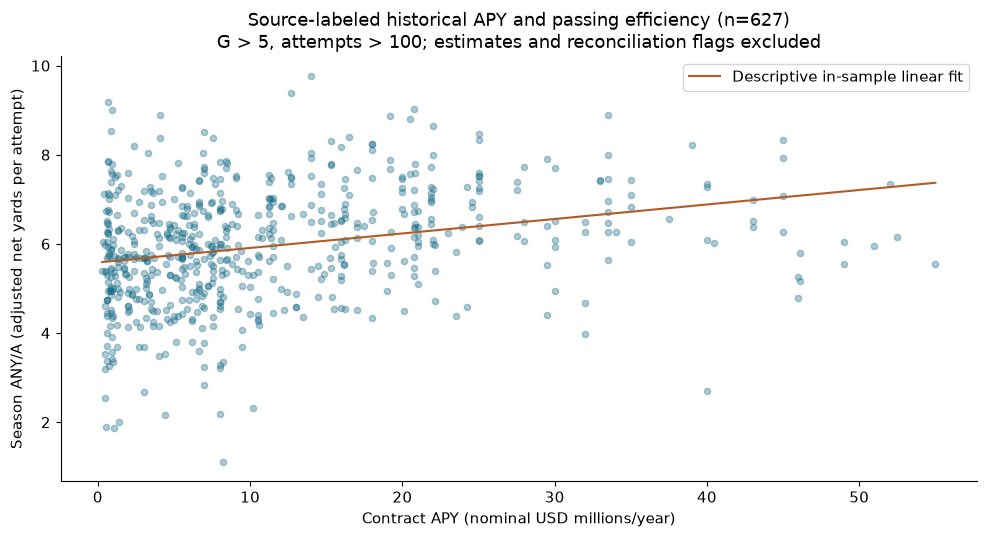

Player,Year,APY_Million,ANYA,Fitted_ANYA,In_Sample_ANYA_Residual
Peyton Manning,2004,14.000,9.776,6.038,3.738
Nick Foles,2013,0.692,9.183,5.605,3.577
Aaron Rodgers,2011,12.704,9.394,5.996,3.398
Brock Purdy,2023,0.934,9.008,5.613,3.395
Patrick Mahomes,2018,4.106,8.888,5.716,3.171
Josh McCown,2013,0.865,8.540,5.611,2.929
Matt Ryan,2016,20.750,9.026,6.257,2.769
Ryan Tannehill,2019,7.000,8.517,5.811,2.707
Peyton Manning,2013,19.200,8.873,6.207,2.666
Patrick Mahomes,2019,4.106,8.381,5.716,2.665


Contract_Year_Signed,contract_tuples,mean_APY_million
1998.0,3,7.085
1999.0,2,6.250
2000.0,4,3.152
2001.0,7,7.392
2002.0,4,5.808
2003.0,2,6.250
2004.0,11,7.921
2005.0,11,6.336
2006.0,5,4.932
2007.0,5,6.129


Unique contract tuples: 318


In [9]:
source = data.Contract_Source.fillna('')
data['Contract_Status'] = np.select([source.str.contains('2026',case=False), source.str.contains('OverTheCap',case=False),data.Contract_APY.isna()],['2026 estimate','source-labeled historical','missing'],default='other/unverified')
data['Contract_Interval_OK'] = (data.Contract_Year_Signed<=data.Year)&(data.Year<data.Contract_Year_Signed+data.Contract_Length)
data['Contract_Positive'] = data[['Contract_Value','Contract_APY','Contract_Length']].gt(0).all(axis=1)
data['APY_Reconciles'] = (data.Contract_Value/data.Contract_Length-data.Contract_APY).abs()<=1
show_table(data.groupby('Contract_Status').agg(rows=('Player','size'),players=('Player','nunique')).reset_index(), 'contract_provenance')
show_table(data.groupby(['Year','Contract_Status']).size().reset_index(name='rows'), 'contract_coverage_by_year')
contract_flags = data.loc[data.Contract_APY.notna() & (~data.Contract_Interval_OK | ~data.Contract_Positive | ~data.APY_Reconciles)]
show_table(contract_flags[['Player','Year','Contract_Status','Contract_Value','Contract_APY','Contract_Year_Signed','Contract_Length','APY_Reconciles']], 'contract_flags')
historical = data.loc[(data.G>5)&(data.Att>100)&data.Contract_Status.eq('source-labeled historical')&data.Contract_Interval_OK&data.Contract_Positive].copy()
contracts = historical.loc[historical.APY_Reconciles].copy()
contracts['APY_Million'] = contracts.Contract_APY/1_000_000
coverage = pd.DataFrame([{'sample':label,'rows':len(f),'players':f.Player.nunique(),'pearson_APY_ANYA':f.Contract_APY.corr(f.ANYA)} for label,f in [('historical before APY reconciliation',historical),('reconciled historical main',contracts)]])
show_table(coverage,'contract_relationship_sensitivity')
assert contracts.Contract_Status.eq('source-labeled historical').all()
assert contracts.APY_Reconciles.all()
plt.figure();plt.scatter(contracts.APY_Million,contracts.ANYA,alpha=.35,s=20,color='#176b87')
slope,intercept=np.polyfit(contracts.APY_Million,contracts.ANYA,1)
x=np.linspace(contracts.APY_Million.min(),contracts.APY_Million.max(),100)
plt.plot(x,slope*x+intercept,color='#b35b24',label='Descriptive in-sample linear fit')
plt.xlabel('Contract APY (nominal USD millions/year)');plt.ylabel('Season ANY/A (adjusted net yards per attempt)')
plt.title(f'Source-labeled historical APY and passing efficiency (n={len(contracts)})\nG > 5, attempts > 100; estimates and reconciliation flags excluded')
plt.legend();save_chart('contract-relationship.png')
contracts['Fitted_ANYA']=slope*contracts.APY_Million+intercept
contracts['In_Sample_ANYA_Residual']=contracts.ANYA-contracts.Fitted_ANYA
show_table(contracts.nlargest(10,'In_Sample_ANYA_Residual')[['Player','Year','APY_Million','ANYA','Fitted_ANYA','In_Sample_ANYA_Residual']], 'descriptive_residuals')
unique_contracts=contracts.drop_duplicates(['Player','Contract_Year_Signed','Contract_Length','Contract_Value','Contract_APY'])
show_table(unique_contracts.groupby('Contract_Year_Signed').agg(contract_tuples=('Player','size'),mean_APY_million=('APY_Million','mean')).reset_index(),'contract_signing_year')
print('Unique contract tuples:',len(unique_contracts))

A contract tuple is only a proxy for a contract ID. Repeated contract/player observations, nominal-dollar time trends, omitted team and player factors, and nonrandom missingness limit the relationship. The residual table is a description of this fitted sample; it is not “best value,” a prediction, a significance test or evidence of underpayment. The ANY/A/APY ratio is retired because it disproportionately rewards small denominators.

## 10. Key Findings

In [10]:
rating_leader=career.loc[career.Rating.idxmax()]
efficiency_leader=career.loc[career.ANYA.idxmax()]
score_leader=career.loc[career.QB_Score.idxmax()]
td_leader=career.loc[career.TD.idxmax()]
findings = [
 f'The workbook contains {len(data):,} records and {data.Year.nunique()} observed seasons; 2007 is missing.',
 f'{rating_leader.Player} leads pooled passer rating ({rating_leader.Rating:.2f}); {efficiency_leader.Player} leads pooled ANY/A ({efficiency_leader.ANYA:.2f}) among {len(career)} eligible players.',
 f'{td_leader.Player} leads observed qualifying-season TD totals ({int(td_leader.TD)}). These are incomplete career windows.',
 f'{score_leader.Player} leads the retained exploratory normalized QB Score ({score_leader.QB_Score:.2f}); weights and overlapping inputs limit interpretation.',
 f'Pooled ANY/A is {era.iloc[0].pooled_ANYA:.2f} in observed 2001–2010 seasons and {era.iloc[1].pooled_ANYA:.2f} in 2011–2020. This is descriptive, with unequal coverage.',
 f'Contract APY and ANY/A have Pearson r={contracts.APY_Million.corr(contracts.ANYA):.3f} across {len(contracts)} reconciled source-labeled historical player-seasons. No significance or causal claim is made.'
]
display(Markdown('\n'.join('- '+s for s in findings)))
(TABLES/'key_findings.json').write_text(__import__('json').dumps(findings,indent=2),encoding='utf-8')

- The workbook contains 2,246 records and 22 observed seasons; 2007 is missing.
- Aaron Rodgers leads pooled passer rating (103.81); Patrick Mahomes leads pooled ANY/A (7.77) among 75 eligible players.
- Tom Brady leads observed qualifying-season TD totals (599). These are incomplete career windows.
- Aaron Rodgers leads the retained exploratory normalized QB Score (94.23); weights and overlapping inputs limit interpretation.
- Pooled ANY/A is 5.59 in observed 2001–2010 seasons and 6.23 in 2011–2020. This is descriptive, with unequal coverage.
- Contract APY and ANY/A have Pearson r=0.272 across 627 reconciled source-labeled historical player-seasons. No significance or causal claim is made.

## 11. Limitations
Missing 2007, partial careers, no position/player IDs, suspicious birth metadata and ambiguous `1D` prevent a complete historical QB evaluation. Passing-only metrics omit rushing, opponent strength, offensive line, scheme and game state. Eligibility introduces selection and survivorship bias; rankings depend on observation windows and cutoffs. Team codes are not harmonized franchises. Age patterns are cross-sectional and provisional.

QB Score retains subjective overlapping weights and a longevity component; it is not validated against an external outcome. Salary provenance is inherited, APY reconciliation excludes potentially legitimate differently defined contracts, missingness is nonrandom, and nominal dollars are not inflation/cap adjusted. Repeated observations and contemporaneous information prevent predictive interpretation. No statistical significance or causal effects are asserted.

For interviews, explain pooled versus equal-season averages, same-frame boolean masks, merge cardinality checks, missing-data provenance, cohort sensitivity, composite-score overlap, and why an association does not establish a causal effect.

In [11]:
assert source_hashes == {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in DATA_DIR.glob('*.xlsx')}
print('Validation complete. Source XLSX hashes unchanged.')

Validation complete. Source XLSX hashes unchanged.
